# Quantum Support Vector Machines para Classificação de Câncer de Mama

Este notebook apresenta a implementação e avaliação experimental de uma Quantum Support Vector Machine (QSVM) aplicada ao conjunto de dados Breast Cancer Wisconsin.

O objetivo é comparar o desempenho de uma QSVM baseada em kernel quântico com uma Máquina de Vetores de Suporte clássica (SVM), utilizando validação cruzada e métricas de classificação como acurácia, precisão, recall e F1-score.

O pipeline experimental inclui:

* Exploração e visualização dos dados;
* Pré-processamento e redução de dimensionalidade com PCA;
* Implementação da SVM clássica;
* Implementação da QSVM utilizando ZZFeatureMap;
* Avaliação estatística por validação cruzada;
* Visualização de circuitos quânticos, kernels e benchmarks.

Ao longo deste notebook serão apresentados os experimentos, resultados e análises comparativas entre as abordagens clássica e quântica.


# 0. Definição de Constantes e Ambiente de Execução

Nesta seção definimos constantes globais e verificamos o ambiente de execução do experimento.

Como os experimentos podem ser executados tanto localmente quanto em um cluster com SLURM, é importante identificar o ambiente para possíveis adaptações futuras (como execução distribuída ou submissão de jobs).

Essa etapa não afeta diretamente os resultados atuais, mas garante reprodutibilidade e escalabilidade do pipeline experimental.

In [1]:
import os

from qml.ellizeu_sena.utils import (
    has_slurm,
    get_partition_status,
)

IS_SLURM = has_slurm()

print(f"Executando em SLURM: {IS_SLURM}")

if IS_SLURM:
    print(get_partition_status("gpu"))

# Caminhos globais do projeto
PROJECT_ROOT = os.path.abspath(
    os.path.join(
        os.getcwd(),
        "..",
        "..",
    )
)
DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "ellizeu_sena",
)
SCRIPTS_PATH = os.path.join(
    PROJECT_ROOT,
    "scripts",
    "ellizeu_sena",
)
PLOT_PATH = os.path.join(
    DATA_PATH,
    "plots",
)

print("DATA_PATH:", DATA_PATH)
print("PLOT_PATH:", PLOT_PATH)

Executando em SLURM: True
{'partition': 'gpu', 'total_nodes': 0, 'idle_nodes': 0, 'mixed_nodes': 0, 'allocated_nodes': 0, 'unavailable_nodes': 0, 'available_nodes': 0}
DATA_PATH: /home/ellizeu.sena/Documentos/pee-886-2026-01/data/ellizeu_sena
PLOT_PATH: /home/ellizeu.sena/Documentos/pee-886-2026-01/data/ellizeu_sena/plots


# 1. Carregamento do Conjunto de Dados

Nesta etapa carregamos o conjunto de dados Breast Cancer Wisconsin e realizamos o pré-processamento inicial.

O pipeline implementado inclui:

- carregamento do dataset;
- padronização dos atributos;
- redução de dimensionalidade opcional utilizando PCA.

Para a análise exploratória inicial utilizaremos os dados sem redução de dimensionalidade.

In [2]:
from qml.ellizeu_sena.loaders import (
    load_breast_cancer_dataset
)
from qml.ellizeu_sena.loaders import (
    download_breast_cancer_dataset
)

X, y, feature_names, target_names = (
    download_breast_cancer_dataset(
        return_metadata=True
    )
)

X_train, X_test, y_train, y_test = (
    load_breast_cancer_dataset(
        use_pca=False
    )
)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = (
    load_breast_cancer_dataset(
        use_pca=True,
        n_components=4,
    )
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


# 2. Análise Exploratória

Nesta seção investigamos as propriedades estatísticas e estruturais do conjunto de dados.

A análise exploratória é essencial para compreender a separabilidade das classes e orientar decisões de pré-processamento como normalização e redução de dimensionalidade.

## 2.1 Visão Geral do Dataset

Inicialmente analisamos as dimensões do conjunto de dados e a distribuição das classes presentes no problema.

In [3]:
from qml.ellizeu_sena.visualization import dataset_summary

dataset_summary(X_train, y_train)

Número de amostras : 455
Número de atributos: 30

Distribuição das classes
Classe 0: 170
Classe 1: 285


## 2.2 Distribuição das Classes

Analisamos o balanceamento entre as classes benigna e maligna.

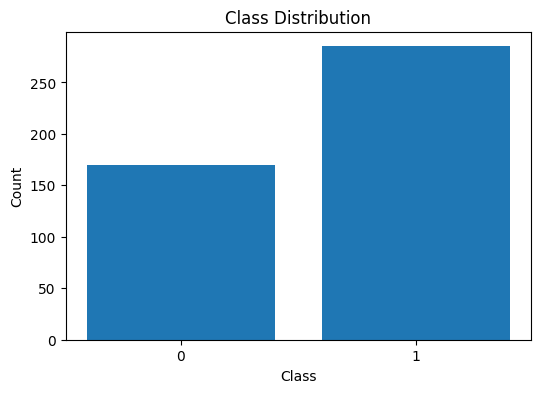

In [4]:
from qml.ellizeu_sena.visualization import plot_class_distribution

plot_class_distribution(
    y_train,
    output_path=f"{PLOT_PATH}/class_distribution.pdf"
)

## 2.3 Estatísticas Descritivas

Apresentamos estatísticas básicas dos atributos do conjunto de dados, incluindo média, desvio padrão, valores mínimos e máximos.

In [5]:
from qml.ellizeu_sena.visualization import (
    descriptive_statistics
)

stats = descriptive_statistics(
    X_train,
    feature_names,
)

stats

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,...,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02
mean,-4.337434e-15,2.240942e-15,-7.437274e-16,1.503071e-16,5.223660e-15,-2.775802e-15,-7.046866e-16,6.031805e-16,-3.263812e-15,-3.031519e-15,...,4.060244e-16,5.676534e-15,-2.402962e-15,-1.022869e-15,4.172487e-15,-5.465713e-16,-6.383172e-16,-4.489693e-16,-1.034581e-15,-2.088683e-15
std,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,...,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00
min,-2.027220e+00,-2.167362e+00,-1.980187e+00,-1.465734e+00,-2.503730e+00,-1.580330e+00,-1.092292e+00,-1.243358e+00,-2.660791e+00,-1.798182e+00,...,-1.730874e+00,-2.191368e+00,-1.695348e+00,-1.238101e+00,-2.715107e+00,-1.421602e+00,-1.282241e+00,-1.707442e+00,-2.081459e+00,-1.571972e+00
25%,-6.958063e-01,-7.379620e-01,-6.979907e-01,-6.758983e-01,-7.210063e-01,-7.504076e-01,-7.492716e-01,-7.233200e-01,-6.728116e-01,-7.179958e-01,...,-6.647169e-01,-7.328464e-01,-6.909317e-01,-6.429737e-01,-7.271308e-01,-6.792384e-01,-7.820068e-01,-7.572169e-01,-6.423407e-01,-6.585793e-01
50%,-2.280663e-01,-9.711800e-02,-2.312101e-01,-3.097848e-01,-3.774691e-02,-2.412686e-01,-3.576338e-01,-4.041472e-01,-8.978972e-02,-1.929345e-01,...,-2.659572e-01,-3.976710e-02,-2.724877e-01,-3.360859e-01,-4.123889e-02,-2.675449e-01,-2.168678e-01,-2.501005e-01,-1.388815e-01,-2.183342e-01
75%,4.785500e-01,5.596334e-01,5.033684e-01,3.526440e-01,6.458845e-01,4.906419e-01,5.266743e-01,6.552186e-01,5.235422e-01,4.796473e-01,...,4.979823e-01,5.986377e-01,5.526388e-01,2.977870e-01,6.157967e-01,5.163947e-01,5.040438e-01,7.284559e-01,4.528766e-01,4.418976e-01
max,4.017353e+00,4.552410e+00,4.018733e+00,5.370416e+00,3.610271e+00,4.517740e+00,4.134445e+00,3.931305e+00,4.399657e+00,4.840942e+00,...,3.557938e+00,3.842120e+00,3.699640e+00,4.640386e+00,3.821065e+00,5.032188e+00,4.522140e+00,2.654689e+00,5.777151e+00,6.719538e+00


## 2.4 Correlação entre Variáveis

Investigamos a correlação entre os atributos do conjunto de dados.

Altos níveis de correlação indicam redundância de informação e justificam o uso de técnicas de redução de dimensionalidade, como PCA.

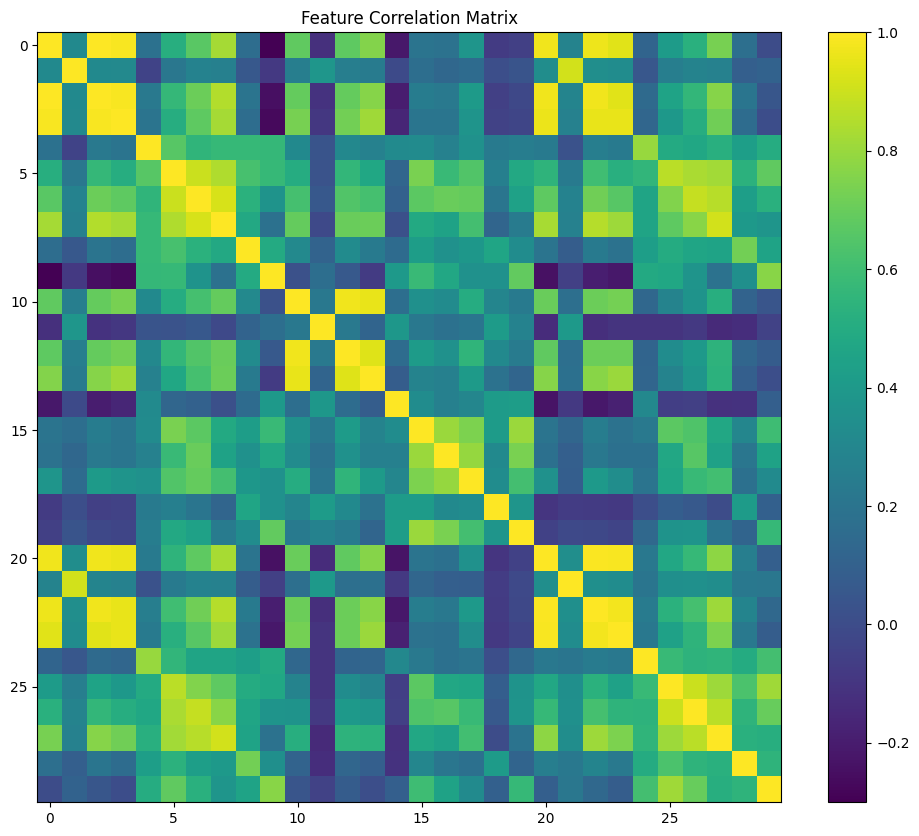

In [6]:
from qml.ellizeu_sena.visualization import (
    plot_correlation_heatmap
)

plot_correlation_heatmap(
    X_train,
    feature_names,
    output_path=f"{PLOT_PATH}/correlation_heatmap.pdf"
)

## 2.5 Distribuição dos Atributos

Visualizamos a distribuição de alguns atributos do conjunto de dados para identificar assimetrias, concentração de valores e possíveis outliers.

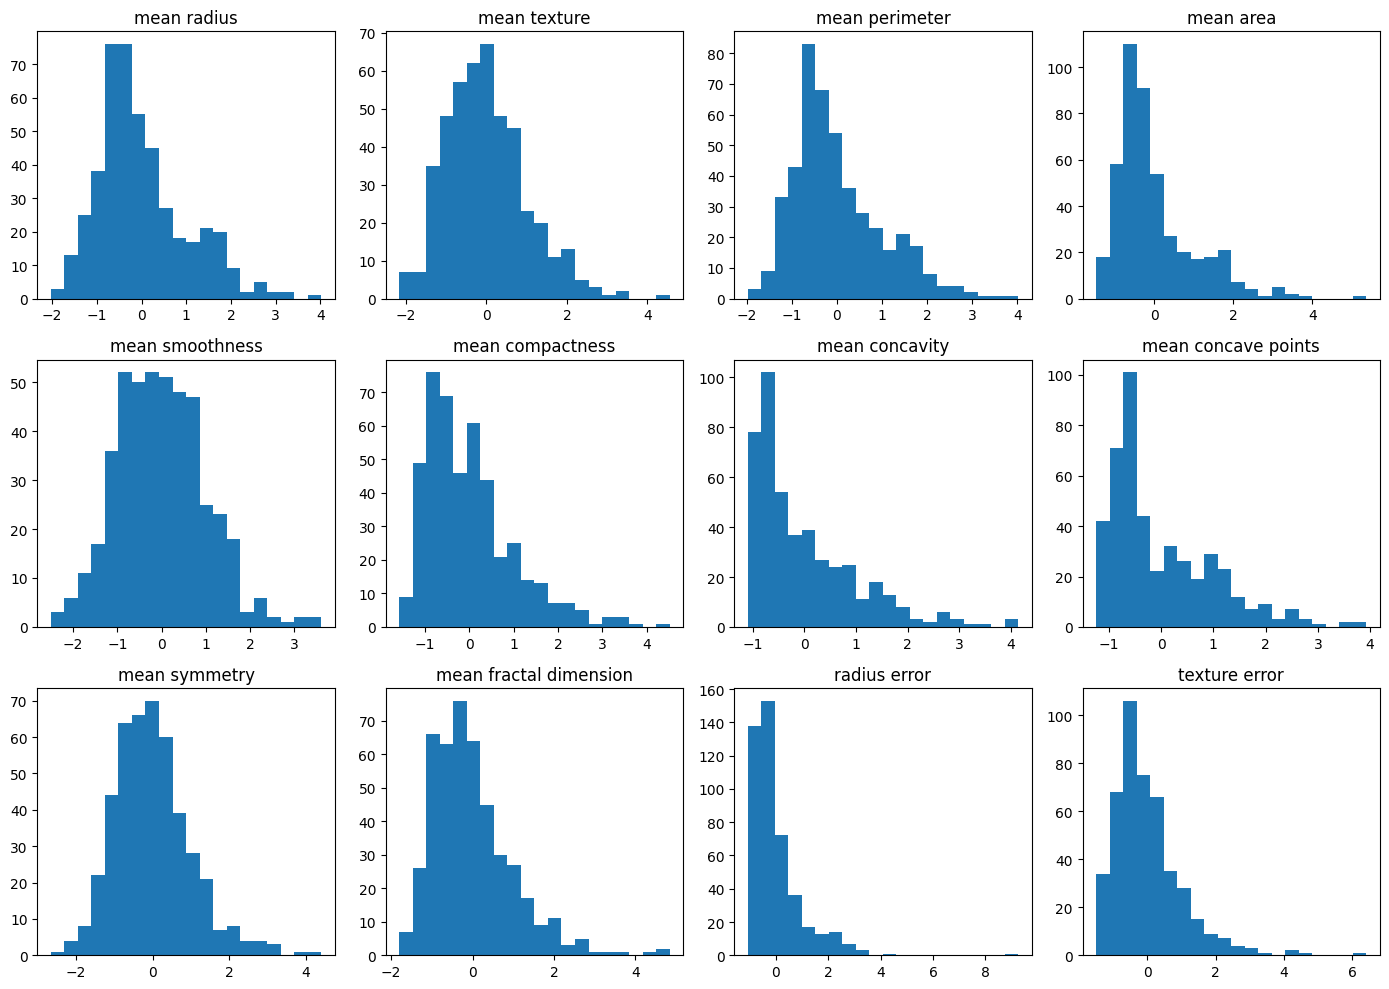

In [7]:
from qml.ellizeu_sena.visualization import (
    plot_feature_histograms
)

plot_feature_histograms(
    X_train,
    feature_names,
)

## 2.6 Análise de Outliers

Os boxplots permitem identificar possíveis valores extremos presentes nos atributos analisados.

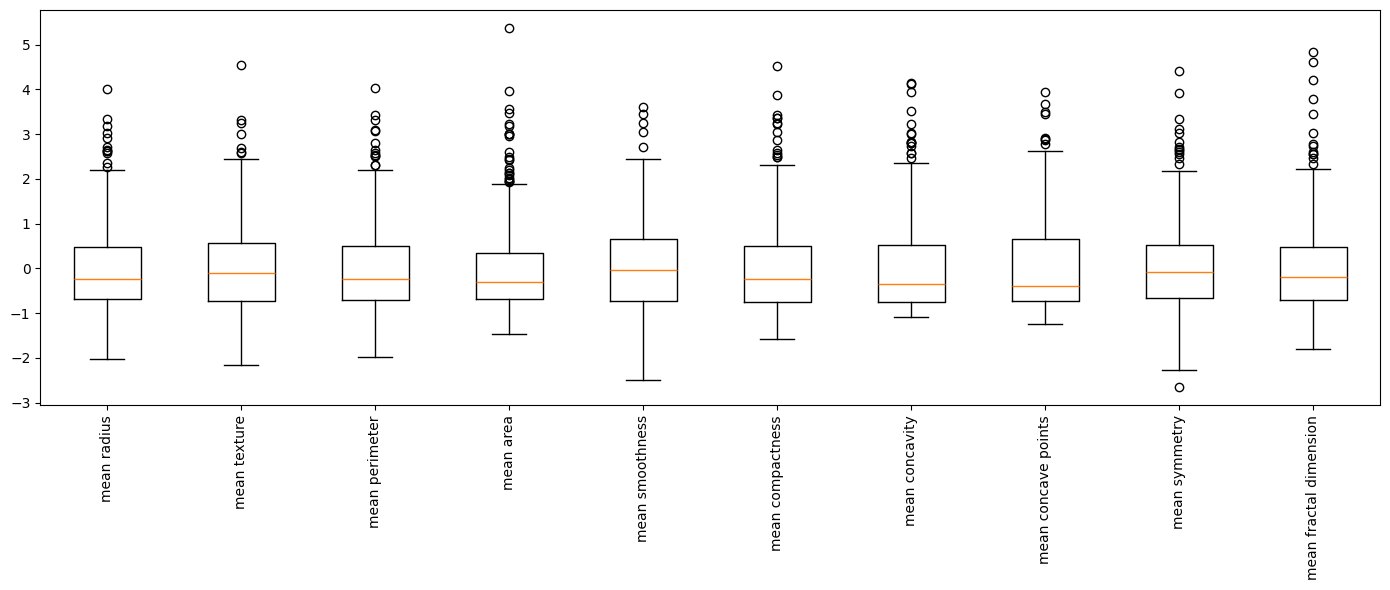

In [8]:
from qml.ellizeu_sena.visualization import (
    plot_feature_boxplots
)

plot_feature_boxplots(
    X_train,
    feature_names,
)

## 2.7 Relações entre Componentes Principais

Após a aplicação do PCA, analisamos a relação entre as componentes principais obtidas.

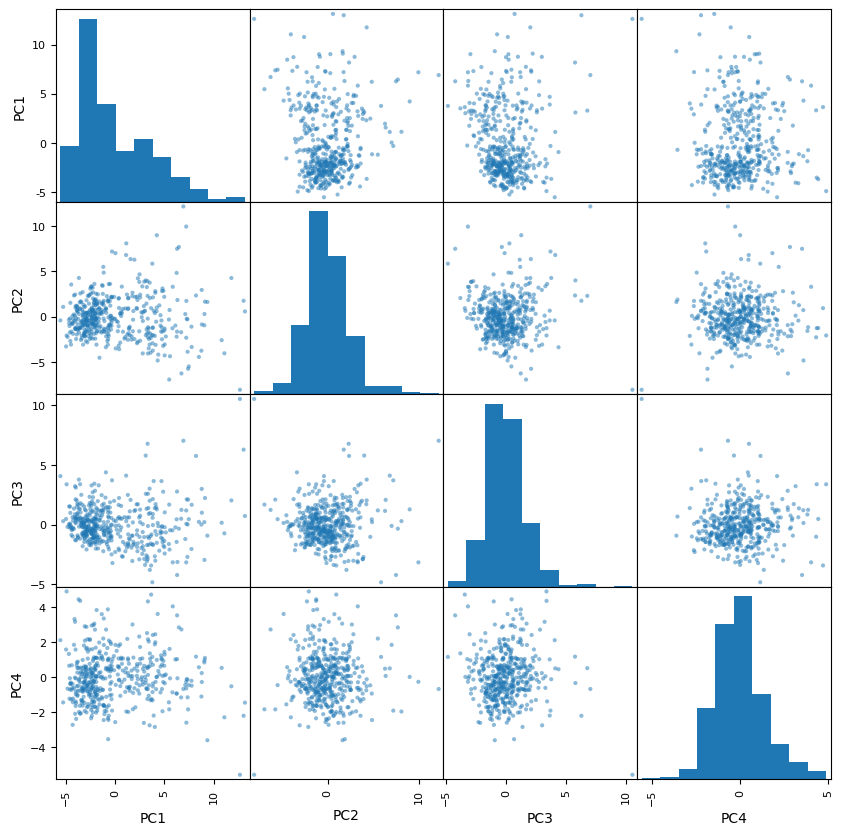

In [9]:
from qml.ellizeu_sena.visualization import (
    plot_pca_pairplot
)

plot_pca_pairplot(
    X_train,
    y_train,
)

## 2.8 Projeção em Duas Dimensões

Aplicamos PCA para visualizar o conjunto de dados em duas dimensões.

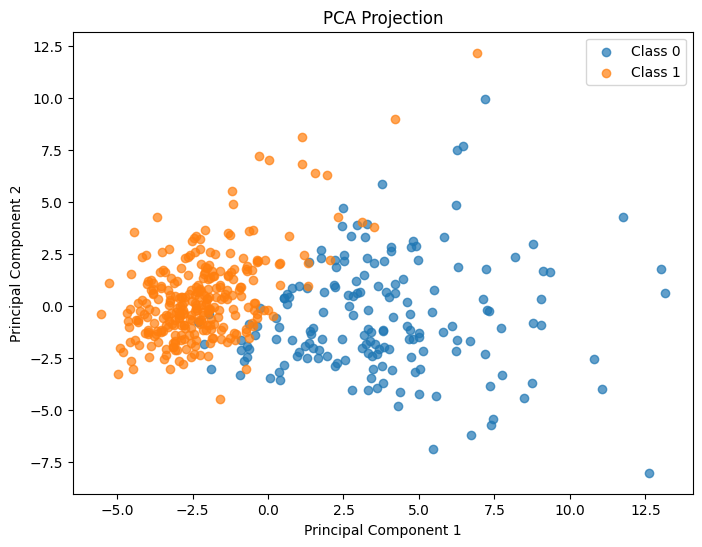

PCA(n_components=2)

In [10]:
from qml.ellizeu_sena.visualization import (
    plot_pca_projection
)

plot_pca_projection(
    X_train,
    y_train,
    output_path=f"{PLOT_PATH}/pca_projection.pdf"
)

## 2.9 Variância Explicada pelo PCA

Por fim, analisamos a quantidade de informação preservada pelas componentes principais, auxiliando na escolha do número de atributos utilizados pelo QSVM.

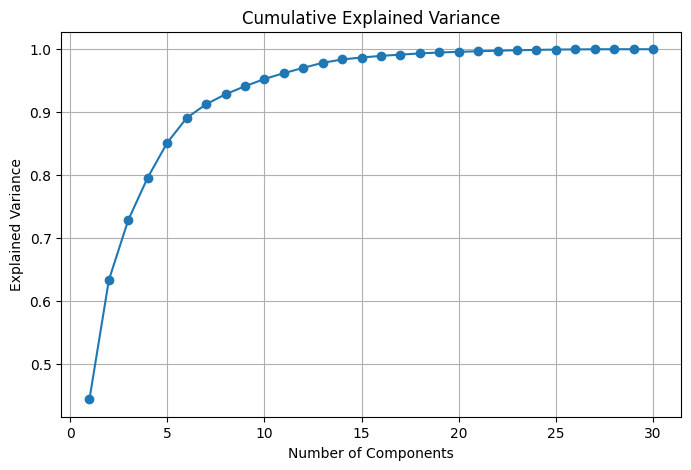

array([0.44413492, 0.6335811 , 0.72901466, 0.79626156, 0.85143846,
       0.8907838 , 0.91260146, 0.92843464, 0.94122247, 0.95267689,
       0.96193959, 0.97041388, 0.97841134, 0.9837184 , 0.98684091,
       0.98941237, 0.99145162, 0.99331859, 0.9948096 , 0.99584631,
       0.99677202, 0.99763844, 0.99835822, 0.99894655, 0.9994512 ,
       0.99969671, 0.99991281, 0.99996999, 0.99999572, 1.        ])

In [11]:
from qml.ellizeu_sena.visualization import (
    plot_explained_variance
)

plot_explained_variance(
    X_train,
    output_path=f"{PLOT_PATH}/explained_variance.pdf"
)

# 3. Treinamento e Seleção de Hiperparâmetros

Nesta etapa serão realizados os experimentos de treinamento dos modelos de classificação clássicos e quânticos.

O processo de treinamento é composto pelas seguintes etapas:

1. Definição dos espaços de busca (grid search) para cada modelo;
2. Avaliação das combinações de hiperparâmetros utilizando validação cruzada estratificada;
3. Registro automático dos resultados obtidos, incluindo métricas de desempenho e tempo de execução;
4. Identificação da melhor configuração de hiperparâmetros para cada modelo;
5. Armazenamento dos resultados para posterior comparação entre as abordagens clássica e quântica.

Quando disponível, o ambiente SLURM poderá ser utilizado para executar os experimentos em nós computacionais do cluster. Caso contrário, os treinamentos serão executados localmente.

Os resultados desta etapa serão utilizados posteriormente para a execução do benchmark final entre o SVM clássico e o QSVM.

In [15]:
from pathlib import Path
import subprocess

from qml.ellizeu_sena.utils import (
    has_slurm,
    get_partition_status,
)

# ----------------------------------
# Ambiente
# ----------------------------------

IS_SLURM = has_slurm()

HAS_AVAILABLE_GPU = False

if IS_SLURM:

    gpu_status = get_partition_status(
        "gpu"
    )

    HAS_AVAILABLE_GPU = (
        gpu_status["available_nodes"] > 0
    )

# ----------------------------------
# Lista de scripts
# ----------------------------------

SCRIPTS_DIR = Path(
    SCRIPTS_PATH
)

SCRIPT_FILES = sorted(
    SCRIPTS_DIR.glob(
        "train_*.py"
    )
)

print("Scripts encontrados:")

for script in SCRIPT_FILES:
    print("-", script)

# ----------------------------------
# Execução
# ----------------------------------

for script in SCRIPT_FILES:

    if HAS_AVAILABLE_GPU:

        sbatch_script = script.with_suffix(
            ".sbatch"
        )

        sbatch_content = f"""#!/bin/bash
#SBATCH --partition=gpu
#SBATCH --job-name={script.stem}
#SBATCH --output={script.stem}.out

python {script}
"""

        with open(
            sbatch_script,
            "w",
        ) as f:
            f.write(
                sbatch_content
            )

        print(
            f"Submetendo {script.name}"
        )

        subprocess.run(
            [
                "sbatch",
                str(sbatch_script),
            ],
            check=True,
        )
        
        sbatch_script.unlink()
        
        print(
            f"Arquivo temporário removido: {sbatch_script.name}"
        )

    else:

        print(
            f"Executando localmente {script.name}"
        )

        subprocess.run(
            [
                "python",
                str(script),
            ],
            check=True,
        )

Scripts encontrados:
- /home/ellizeu.sena/Documentos/pee-886-2026-01/scripts/ellizeu_sena/train_classical_svm_1.py
- /home/ellizeu.sena/Documentos/pee-886-2026-01/scripts/ellizeu_sena/train_classical_svm_2.py
- /home/ellizeu.sena/Documentos/pee-886-2026-01/scripts/ellizeu_sena/train_quantum_svm_1.py
Executando localmente train_classical_svm_1.py
Skipping existing: {'C': 0.1, 'gamma': 'scale'}
Skipping existing: {'C': 0.1, 'gamma': 0.1}
Skipping existing: {'C': 0.1, 'gamma': 0.01}
Skipping existing: {'C': 0.1, 'gamma': 0.001}
Skipping existing: {'C': 1, 'gamma': 'scale'}
Skipping existing: {'C': 1, 'gamma': 0.1}
Skipping existing: {'C': 1, 'gamma': 0.01}
Skipping existing: {'C': 1, 'gamma': 0.001}
Skipping existing: {'C': 10, 'gamma': 'scale'}
Skipping existing: {'C': 10, 'gamma': 0.1}
Skipping existing: {'C': 10, 'gamma': 0.01}
Skipping existing: {'C': 10, 'gamma': 0.001}
Skipping existing: {'C': 100, 'gamma': 'scale'}
Skipping existing: {'C': 100, 'gamma': 0.1}
Skipping existing: {'C'

# 4. Avaliação no Conjunto de Teste

Após a seleção dos hiperparâmetros por validação cruzada e o treinamento final dos modelos utilizando todo o conjunto de treinamento, é necessário avaliar o desempenho em dados não vistos durante o processo de desenvolvimento.

Nesta etapa, utilizamos o conjunto de teste separado anteriormente para estimar a capacidade de generalização dos modelos.

Serão avaliados:

- Classical SVM
- Classical SVM com PCA
- Quantum SVM com PCA

As seguintes métricas serão reportadas:

- Accuracy
- Precision
- Recall
- F1-Score

Além disso, serão comparadas as matrizes de confusão dos modelos para análise dos erros de classificação.

In [12]:
from qml.ellizeu_sena.loaders import (
    download_breast_cancer_dataset,
    split_dataset,
    preprocessing_pipeline,
)

from qml.ellizeu_sena.models import (
    ClassicalSVM,
    QuantumSVM,
)

from qml.ellizeu_sena.evaluation import (
    evaluate_saved_model,
)

{'accuracy': 0.9473684210526315,
 'precision': 0.9583333333333334,
 'recall': 0.9583333333333334,
 'f1_score': 0.9583333333333334,
 'confusion_matrix': array([[39,  3],
        [ 3, 69]])}

In [13]:
classical_results = evaluate_saved_model(
    model_class=ClassicalSVM,
    model_path=os.path.join(
        DATA_PATH,
        "models",
        "classical_svm_with_pca.joblib",
    ),
    X_test=X_test_pca,
    y_test=y_test_pca,
)

classical_results

{'accuracy': 0.9473684210526315,
 'precision': 0.9583333333333334,
 'recall': 0.9583333333333334,
 'f1_score': 0.9583333333333334,
 'confusion_matrix': array([[39,  3],
        [ 3, 69]])}

In [14]:
quantum_results = evaluate_saved_model(
    model_class=QuantumSVM,
    model_path=os.path.join(
        DATA_PATH,
        "models",
        "quantum_svm_with_pca.joblib",
    ),
    X_test=X_test_pca,
    y_test=y_test_pca,
)

quantum_results

TypeError: __init__() missing 1 required positional argument: 'num_features'